# Visualize the results obtained in ValidateDatacube.ipynb

In [1]:
# from src.DatacubeValidation.GetResults import *
from src.DatacubeValidation.GetResults import load_result_geodataframe, plot_results
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats.mstats import winsorize
from src.config import AEMET_VALIDATION_RESUTLS_DIR, FIGURES_DIR

gdf_MAE = load_result_geodataframe(metric="MAE")
gdf_NMAE = load_result_geodataframe(metric="NormalizedMAE")

2025-04-30 15:53:23.282 | INFO     | src.config:<module>:13 - PROJ_ROOT path is: C:\Workspace\Projects\IberFire


## Geospatial mapping of Errors, Violin plots of Normalized Errors and Density plots of Normalized Errors

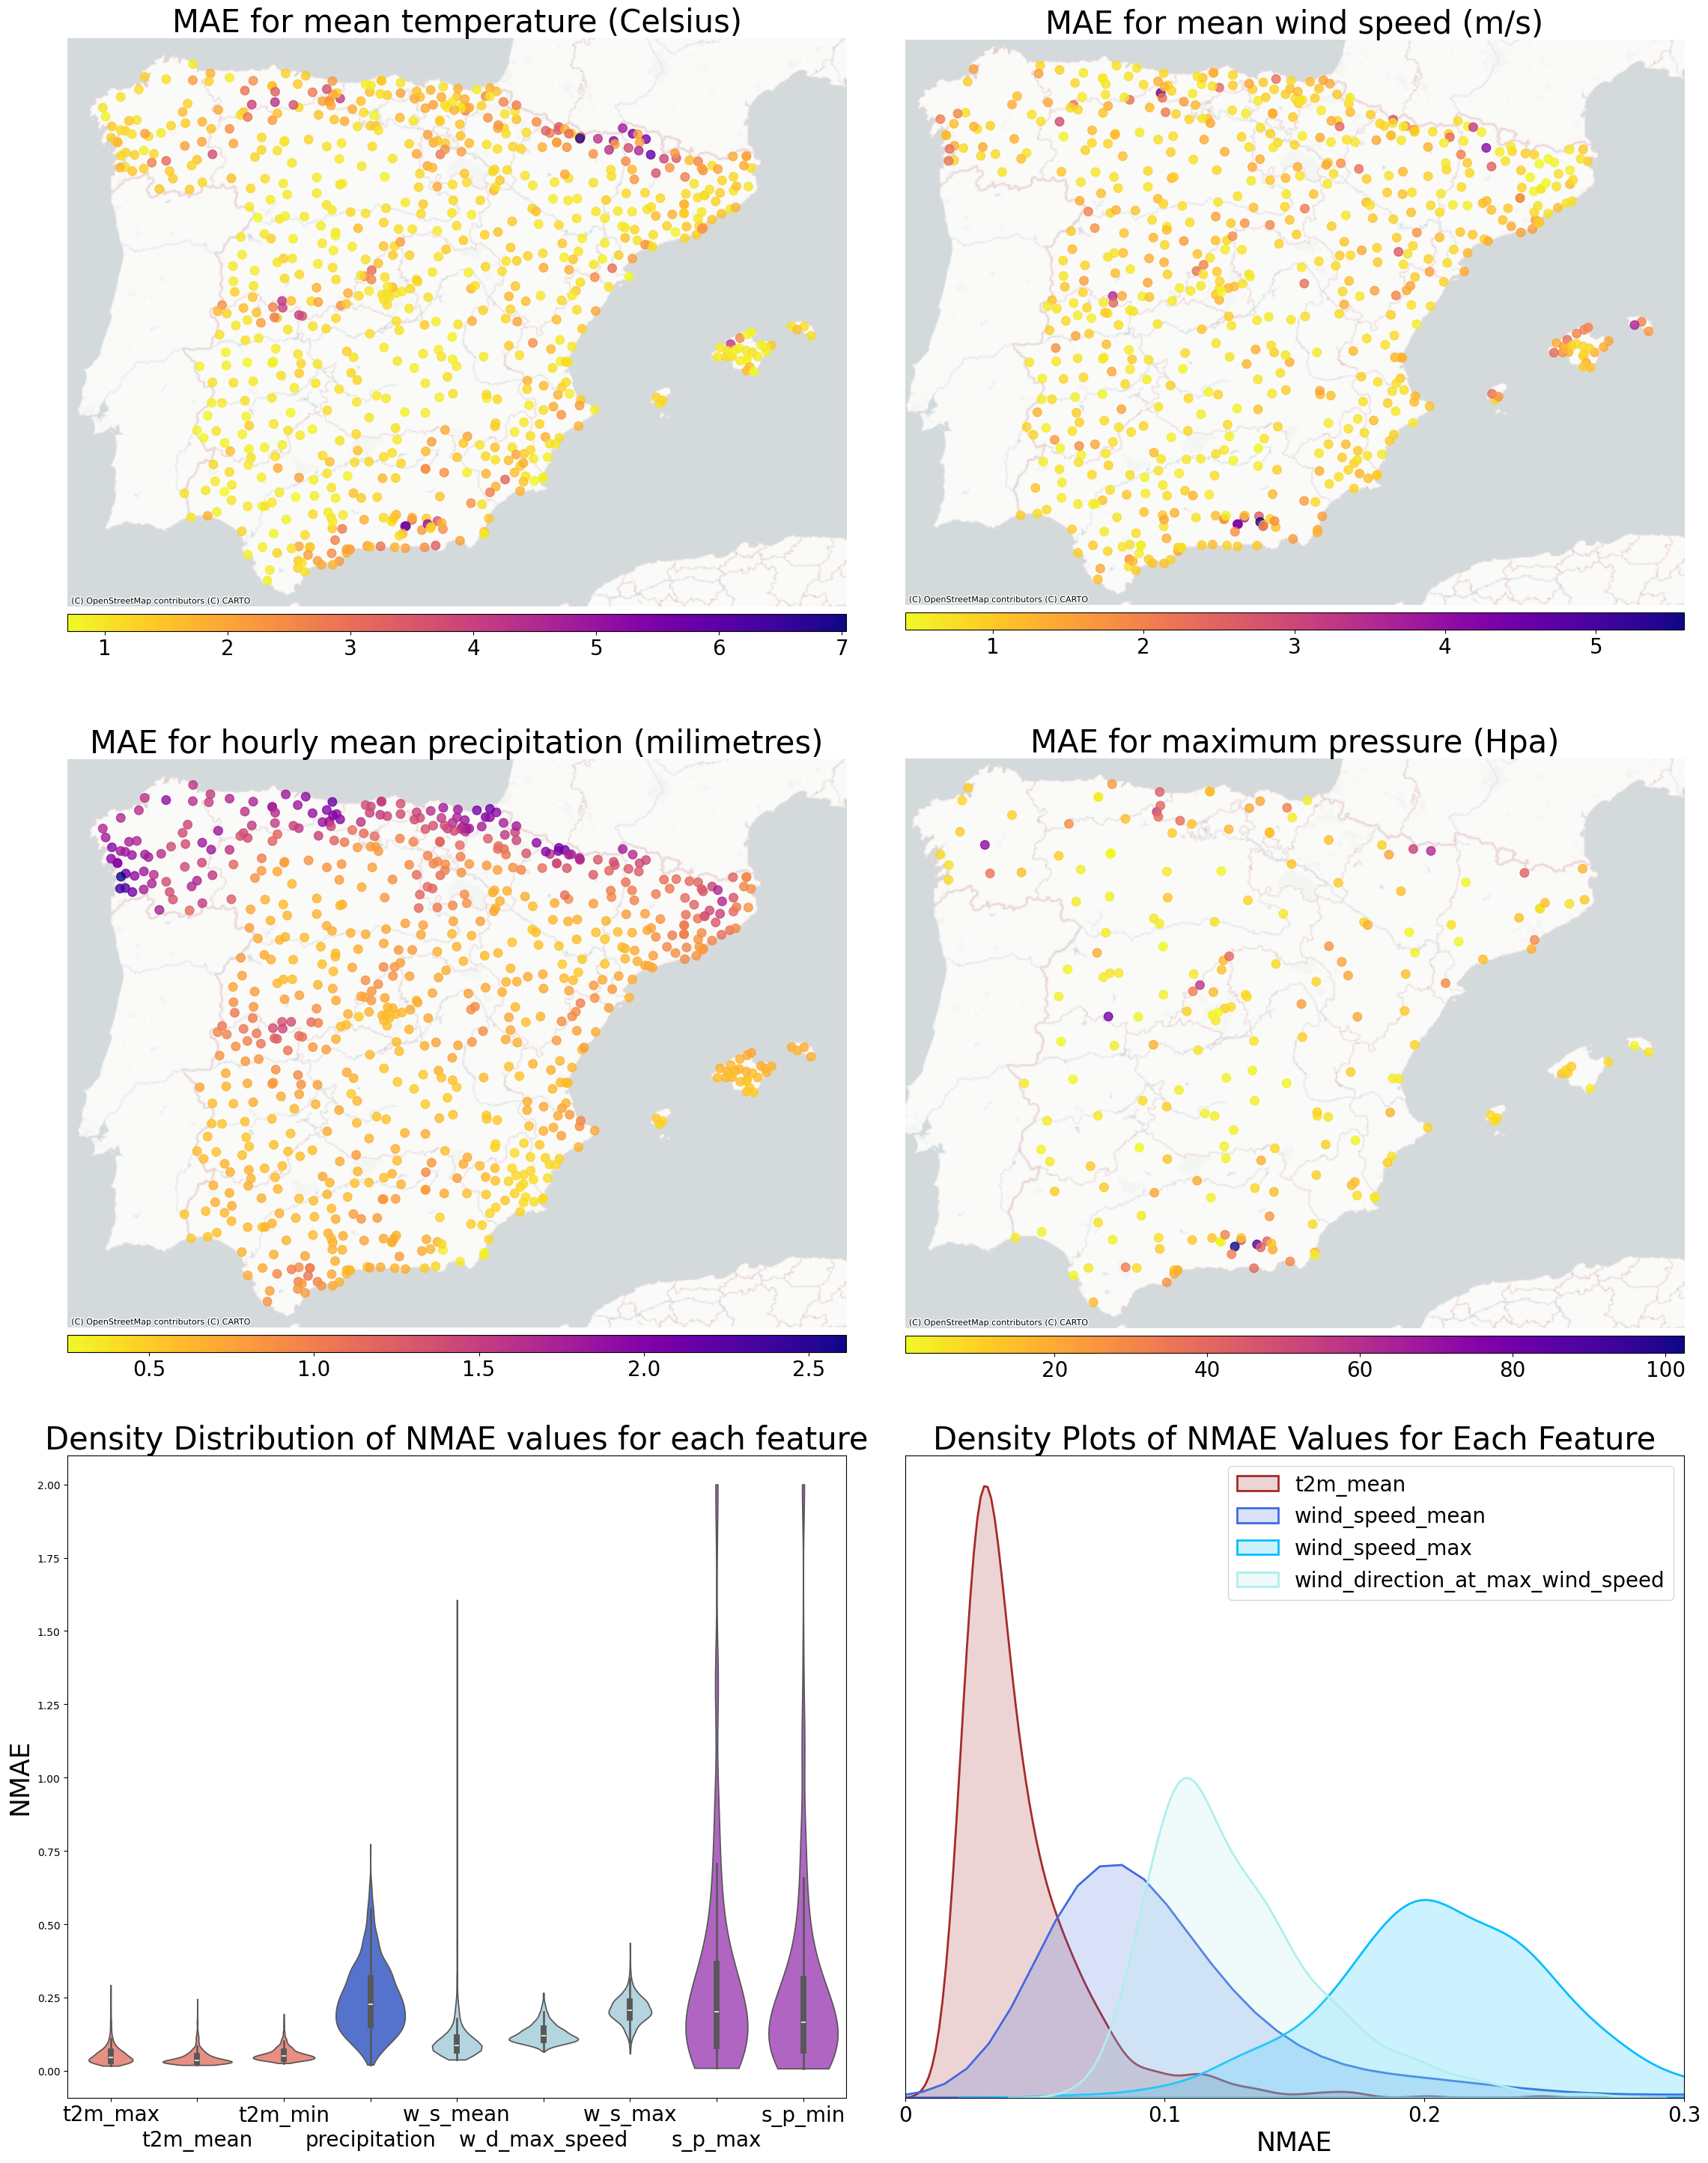

In [2]:
plotting_features = ["TMEDIA", "PRECIPITACION", "VELMEDIA", "PRESMAX"]
title_mapping = {
    "TMEDIA": "mean temperature (Celsius)",
    "PRECIPITACION": "hourly mean precipitation (milimetres)",
    "VELMEDIA": "mean wind speed (m/s)",
    "PRESMAX": "maximum pressure (Hpa)",
}

fig, ax = plt.subplots(3, 2, figsize=(24,30))

# Plotting MAE maps
for i, feature in enumerate(plotting_features):
    j = i // 2
    a = i % 2
    plot_results(gdf_MAE, feature, ax[a, j], error_metric="MAE", title=f"MAE for {title_mapping[feature]}")

    plt.tight_layout()

# Plotting NMAE violin plots
features_to_validate = ["TMAX", "TMEDIA", "TMIN", "PRECIPITACION", "VELMEDIA", "DIR", "RACHA", "PRESMAX", "PRESMIN"]
df_long = gdf_NMAE[features_to_validate].melt(var_name='Feature', value_name='MAE')
group_mapping = {
    "TMAX": "Temperature",
    "TMIN": "Temperature",
    "TMEDIA": "Temperature",
    "PRECIPITACION": "Precipitation",
    "DIR": "Wind",
    "VELMEDIA": "Wind",
    "RACHA": "Wind",
    "PRESMAX": "Pressure",
    "PRESMIN": "Pressure"
}
df_long['Group'] = df_long['Feature'].map(group_mapping)
custom_palette = {
    "Temperature": "salmon",   
    "Precipitation": "royalblue",   
    "Wind": "#ADD8E6",           
    "Pressure": "mediumorchid" 
}
df_clipped = df_long.copy()
df_clipped['MAE'] = df_clipped['MAE'].clip(upper=2) # Limit NMAE values for plotting

sns.violinplot(x='Feature', y='MAE', data=df_clipped, ax = ax[2,0], hue='Group', 
               palette=custom_palette, dodge=False, legend=False, cut=0)
ax[2,0].set_title("Density Distribution of NMAE values for each feature", fontsize=30)
ax[2,0].set_xlabel("") 
ax[2,0].set_ylabel("NMAE", fontsize=25)
new_labels = ["t2m_max", "\nt2m_mean", "t2m_min", "\nprecipitation", "w_s_mean", "\nw_d_max_speed", "w_s_max", "\ns_p_max", "s_p_min"]
ax[2,0].set_xticks(range(9))
ax[2,0].set_xticklabels(new_labels, fontsize=20)
plt.tight_layout()

# Plotting density distributions of NMEAE values
plotting_features = ["TMEDIA", "VELMEDIA","RACHA", "DIR"]
df_long = gdf_NMAE[plotting_features].melt(var_name='Feature', value_name='MAE')
color_mapping = {
    "TMEDIA": "#A52A2A",     
    "DIR": "paleturquoise",        
    "VELMEDIA": "royalblue",     
    "RACHA": "deepskyblue",        
    "PRESMAX": "#800080"       
}
for feature in plotting_features:
    subset = df_long[df_long['Feature'] == feature]
    sns.kdeplot(subset["MAE"], label=feature, color=color_mapping[feature], fill=True, alpha=0.2, ax=ax[2,1], linewidth=2)
ax[2,1].set_title("Density Plots of NMAE Values for Each Feature", fontsize=30)
ax[2,1].set_xlabel("NMAE", fontsize=25)
ax[2,1].set_ylabel("")
ax[2,1].legend(title="", fontsize=20, title_fontsize=25, loc='upper right')
ax[2,1].set_yticks([])
ax[2,1].set_xlim(0, 0.3)
ax[2,1].set_xticks(ticks = [0, 0.1, 0.2, 0.3], labels = [0, 0.1, 0.2, 0.3], fontsize=20)

# After plotting the density distributions on ax[2,1]
handles, labels = ax[2,1].get_legend_handles_labels()

# Define your new desired labels, making sure the list order matches the original handles order.
new_labels = ["t2m_mean", "wind_speed_mean", "wind_speed_max", "wind_direction_at_max_wind_speed", "PREC"]

# Re-create the legend using the new labels.
ax[2,1].legend(handles, new_labels, title="", fontsize=20, title_fontsize=25, loc='upper right')

plt.tight_layout(pad=5)

plt.savefig(FIGURES_DIR / "validation_result_maps.pdf", dpi=300, bbox_inches="tight", format="pdf")


## Calculate mean, stdev and number of NaN values for MAE and NMEA

In [3]:
features_to_validate = ["TMAX", "TMEDIA", "TMIN", "PRECIPITACION", "VELMEDIA", "DIR", "RACHA", "PRESMAX", "PRESMIN"]
summary_metrics = pd.DataFrame(
    {
        feature: [
            gdf_MAE[feature].mean(),
            gdf_MAE[feature].std(),
            gdf_NMAE[feature].mean(),
            gdf_NMAE[feature].std(),
            gdf_MAE[feature].isna().sum()
        ]
        for feature in features_to_validate
    },
    index=["mean_MAE", "stdev_MAE", "mean_NMAE", "stdev_NMAE", "#NA_values"]
)
# display(summary_metrics.round(3))
display(summary_metrics)

,TMAX,TMEDIA,TMIN,PRECIPITACION,VELMEDIA,DIR,RACHA,PRESMAX,PRESMIN
mean_MAE,2.172681,1.495032,1.828893,0.918146,1.045737,46.115499,5.855972,13.994863,13.738493
stdev_MAE,1.215353,0.814971,0.732074,0.422252,0.562684,11.840580,1.728070,15.545706,15.531169
mean_NMAE,0.054666,0.044807,0.057617,0.245620,0.104158,0.128185,0.208769,0.355628,0.311632
stdev_NMAE,0.031540,0.025513,0.023546,0.118352,0.080141,0.032945,0.047040,0.629235,0.603140
#NA_values,58.000000,58.000000,58.000000,67.000000,169.000000,169.000000,169.000000,605.000000,605.000000
